# Data-Efficiency Experiment
Runs data_efficiency.py: ResNet50 trained on increasing fractions of a FIELD dataset (ImageNet init). Field set built from FGVC8 (PlantPathology2021) single-label images, mapped to 4 classes (apple_scab, black_rot[frogeye], cedar_apple_rust, healthy).

In [1]:
import subprocess, sys
print(sys.executable)
r = subprocess.run([sys.executable, '-c', 'import torch;print(torch.__version__, torch.cuda.is_available())'], capture_output=True, text=True)
print(r.stdout, r.stderr)

C:\Users\cy\AppData\Local\Programs\Python\Python310\python.exe


2.6.0+cu124 True
 


## 1. Build field dataset (FGVC8 -> 4-class ImageFolder)

In [2]:
r = subprocess.run([sys.executable, 'scripts/build_field_dir.py'], capture_output=True, text=True)
print(r.stdout)
print(r.stderr)

[apple_scab] 500 images -> field_data\apple_scab
[black_rot] 500 images -> field_data\black_rot
[cedar_apple_rust] 500 images -> field_data\cedar_apple_rust
[healthy] 500 images -> field_data\healthy




## 2. Run data_efficiency.py (ImageNet-init curve; workers=8 to parallelize full-res JPEG decode)

In [3]:
proc = subprocess.Popen(
    [sys.executable, 'data_efficiency.py', '--field_dir', 'field_data',
     '--fractions', '10,50,100', '--seeds', '2', '--epochs', '4',
     '--batch', '32', '--workers', '8', '--out', 'runs_de'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='')
proc.wait()
print('exit code:', proc.returncode)

[info] device = cuda
[imagenet] frac= 10.0% seed=0 n_train= 160 acc=0.5500 macroF1=0.5297
[imagenet] frac= 10.0% seed=1 n_train= 160 acc=0.5925 macroF1=0.5844
[imagenet] frac= 50.0% seed=0 n_train= 800 acc=0.9200 macroF1=0.9198
[imagenet] frac= 50.0% seed=1 n_train= 800 acc=0.9025 macroF1=0.9023
[imagenet] frac=100.0% seed=0 n_train=1600 acc=0.9575 macroF1=0.9574
[imagenet] frac=100.0% seed=1 n_train=1600 acc=0.9350 macroF1=0.9348
SUMMARY imagenet  10.0%  macroF1 = 0.557 +/- 0.027
SUMMARY imagenet  50.0%  macroF1 = 0.911 +/- 0.009
SUMMARY imagenet 100.0%  macroF1 = 0.946 +/- 0.011
[ok] plot -> runs_de\data_efficiency_curve.png

[done] send back the whole runs_de folder (CSV + PNG + raw_results.json).


exit code: 0


## 3. Results

In [4]:
import pandas as pd
df = pd.read_csv('runs_de/data_efficiency.csv')
df

,init,field_fraction_%,macroF1_mean,macroF1_sd,n_seeds
0,imagenet,10.0,0.5570,0.0274,2
1,imagenet,50.0,0.9111,0.0087,2
2,imagenet,100.0,0.9461,0.0113,2


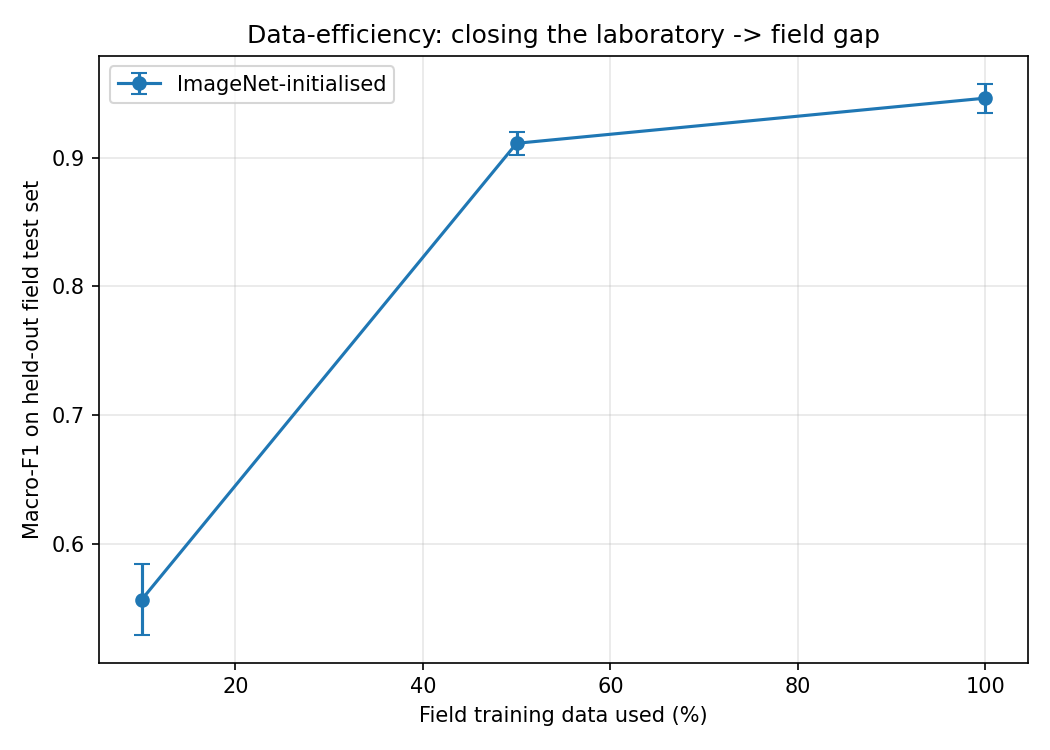

In [5]:
from IPython.display import Image
Image(filename='runs_de/data_efficiency_curve.png')